In [7]:
import _pickle as pickle
import matplotlib.pyplot as plt
import numpy as np
import os
import torch
import torch.optim as optim
import torch.nn.functional as F

from envs import TFAugmentedFrozenLakeEnv
from policies import ThoughtMLP, ThoughtNN

from tqdm.notebook import tqdm

## Generate expert data

In [2]:
num_cells = 16
save_path = "expert_data-tabular.pt"

config_path = "/home/bryanpu1/projects/thinking-as-control/EXPS/frozen_lake-ppo/no_thought_acts-tabular_42-args.pkl"
model_path = "/home/bryanpu1/projects/thinking-as-control/EXPS/frozen_lake-ppo/no_thought_acts-tabular-42.pt"

In [3]:
if os.path.isfile(save_path):
    data_dict = pickle.load(open(save_path, "rb"))
    states = data_dict["obss"]
    actions = data_dict["acts"]
else:
    config = pickle.load(open(config_path, "rb"))
    policy = torch.load(model_path, weights_only=False)
    d_model = config.d_model

    states = torch.eye(num_cells)

    logits, _ = policy(torch.cat((
        states,
        torch.zeros((num_cells, d_model)),
    ), dim=1))
    actions = torch.argmax(logits, dim=-1)

    pickle.dump({
        "obss": states,
        "acts": actions,
    }, open(save_path, "wb"))

## Behavioural cloning

In [4]:
n_thought_states = 1
n_thought_acts = 0
max_steps = 1
tabular = False
d_model = 8

lr = 1e-2
num_epochs = 10000

In [5]:
env = TFAugmentedFrozenLakeEnv(
        n_thought_states=n_thought_states,
        n_thought_acts=n_thought_acts,
        d_model=d_model,
        max_steps=max_steps,
        tabular=tabular,
    )

policy = ThoughtNN(
    obs_dim=env.obs_dim,
    n_acts=env.n_acts,
    n_thought_acts=n_thought_acts,
    d_model=d_model,
)
policy = ThoughtMLP(
    obs_dim=env.obs_dim,
    n_acts=env.n_acts,
    n_thought_acts=n_thought_acts,
    d_model=d_model,
)
policy_optimizer = optim.Adam(policy.parameters(), lr=lr, weight_decay=0.0)

enc_obss = torch.cat((
    torch.argmax(states, dim=-1, keepdims=True),
    torch.zeros((num_cells, d_model)),
), dim=1)

  0%|          | 0/10000 [00:00<?, ?it/s]

Optimal action accuracy for sequence 0: 0.5


  0%|          | 0/10000 [00:00<?, ?it/s]

Optimal action accuracy for sequence 1: 0.5


  0%|          | 0/10000 [00:00<?, ?it/s]

Optimal action accuracy for sequence 2: 0.6666666666666666


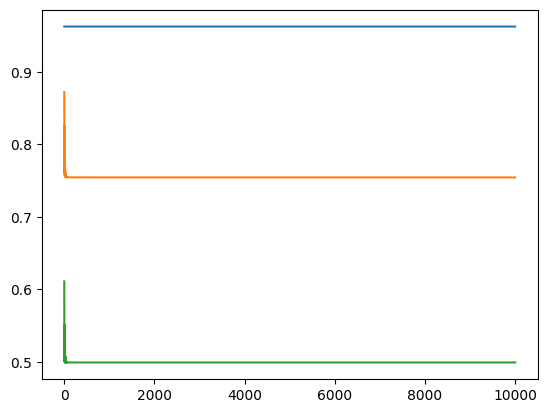

In [9]:
path_1 = [0, 1, 2, 6, 10, 14]
path_2 = [0, 4, 8, 9, 10, 14]
path_3 = [0, 4, 8, 9, 13, 14]
for path_i, curr_opt_path in enumerate((
    path_1,
    path_2,
    path_3,
)):
    losses = []
    for _ in tqdm(range(num_epochs)):
        logits, _ = policy(enc_obss[curr_opt_path])
        loss = F.cross_entropy(logits, actions[curr_opt_path]).mean()
        policy_optimizer.zero_grad()
        loss.backward()
        policy_optimizer.step()
        losses.append(loss.item())
    plt.plot(range(num_epochs), losses, label=f"Optimal Path {path_i}")

    logits, _ = policy(enc_obss)
    pred_acts = torch.argmax(logits, dim=-1)
    print("Optimal action accuracy for sequence {}: {}".format(
        path_i,
        np.mean((pred_acts == actions)[curr_opt_path].numpy())
    ))
plt.show()